# World Energy Consumption - General EDA

**Target variable:** `renewables_share_energy` - the percentage of a country's total energy that comes from renewable sources in a given year (0-100)

**Purpose of this notebook:** Understand the dataset structure, validate the target variable, explore correlations across all features, and identify which features are genuinely predictive vs. circular. The findings here directly inform the feature selection for Model 1 (MLP), Model 2 (Bayesian Regression) and Model 3 (ARIMA).

---
## Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET    = 'renewables_share_energy'
DATA_PATH = '../data/World_Energy_Consumption.csv'  # update path if needed

---
## 1. Load Data and Basic Inspection

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 22,012 rows x 129 columns


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,...,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.60,1.52,NaN,500.23,NaN,NaN,NaN,NaN,NaN,71.03,NaN,NaN,NaN,NaN,19.27,...,NaN,NaN,NaN,NaN,NaN,72.90,NaN,19.77,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.02,1.52,NaN,499.36,NaN,NaN,NaN,NaN,NaN,80.02,NaN,NaN,NaN,NaN,20.15,...,NaN,NaN,NaN,NaN,NaN,76.68,NaN,19.31,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.06,1.43,NaN,505.65,NaN,NaN,NaN,NaN,NaN,87.16,NaN,NaN,NaN,NaN,20.61,...,NaN,NaN,NaN,NaN,NaN,75.99,NaN,17.97,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN


In [4]:
# Column dtypes overview
df.dtypes.value_counts()

float64    126
str          2
int64        1
Name: count, dtype: int64

In [5]:
# Year range and unique countries
print(f'Year range: {df["year"].min()} to {df["year"].max()}')
print(f'Unique countries: {df["country"].nunique()}')
print(f'\nSample countries:\n{df["country"].unique()[:15]}')

Year range: 1900 to 2022
Unique countries: 306

Sample countries:
<StringArray>
[      'ASEAN (Ember)',         'Afghanistan',              'Africa',
         'Africa (EI)',      'Africa (Ember)',      'Africa (Shift)',
             'Albania',             'Algeria',      'American Samoa',
              'Angola',          'Antarctica', 'Antigua and Barbuda',
           'Argentina',             'Armenia',               'Aruba']
Length: 15, dtype: str


---
## 2. Target Variable: Sanity Checks

Before any modeling, we verify the target has no structural problems: no out-of-range values, reasonable missing rate, and a distribution we understand.

In [6]:
n_total = len(df)
n_missing = df[TARGET].isna().sum()
print(f'Missing values: {n_missing:,} / {n_total:,} ({n_missing/n_total*100:.1f}%)')

# Range validation (must be 0-100)
out_of_range = df[(df[TARGET] < 0) | (df[TARGET] > 100)]
print(f'Out-of-range values  : {len(out_of_range)}')
if len(out_of_range) > 0:
    display(out_of_range[['country', 'year', TARGET]])

Missing values: 17,225 / 22,012 (78.3%)
Out-of-range values  : 0


In [7]:
# Descriptive statistics
desc = df[TARGET].describe(percentiles=[.05, .25, .5, .75, .95])
print(desc)
print(f'\nSkewness : {df[TARGET].skew():.3f}')
print(f'Kurtosis : {df[TARGET].kurtosis():.3f}')

count   4787.00
mean      11.19
std       11.84
min        0.00
5%         0.19
25%        3.41
50%        7.04
75%       14.74
95%       33.80
max       74.30
Name: renewables_share_energy, dtype: float64

Skewness : 1.933
Kurtosis : 4.836


---
## 3. Univariate Distribution

The target is strongly right-skewed: most countries have low renewable share, while a small number of hydro-heavy countries (Norway, Brazil, Iceland) sit far to the right. This is important context for interpreting model residuals. The model will tend to be more accurate in the dense 0-20% range than at the extremes.

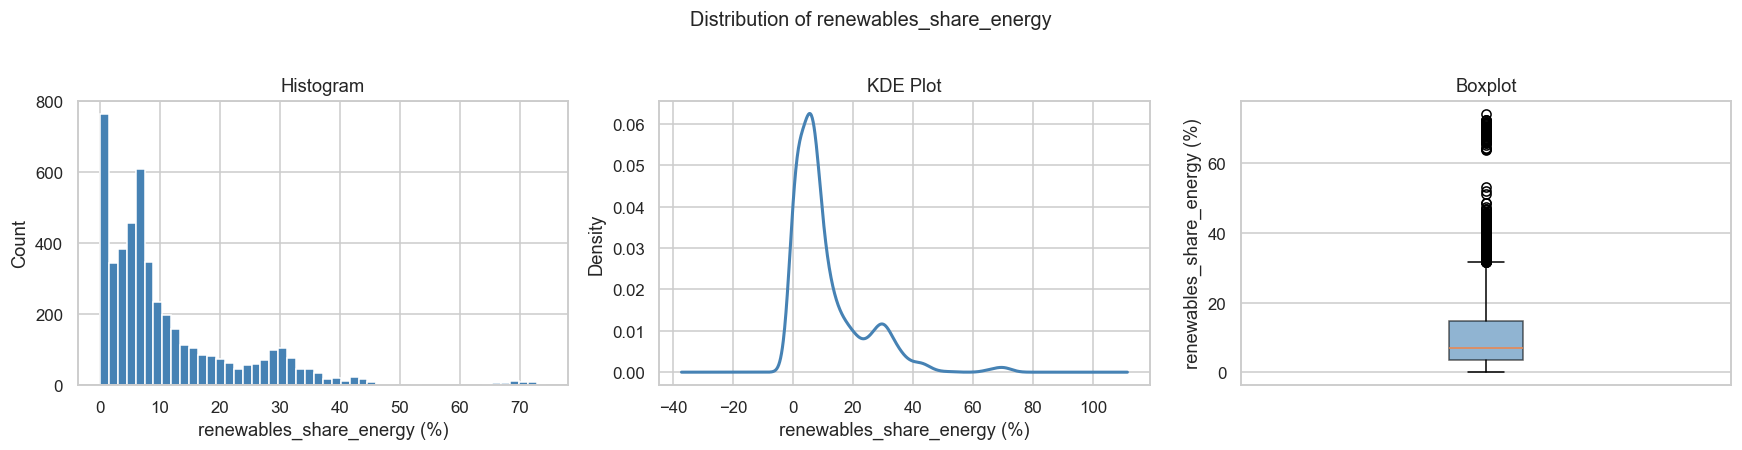

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('renewables_share_energy (%)')
axes[0].set_ylabel('Count')

df[TARGET].dropna().plot(kind='kde', ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('KDE Plot')
axes[1].set_xlabel('renewables_share_energy (%)')

axes[2].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Boxplot')
axes[2].set_ylabel('renewables_share_energy (%)')
axes[2].set_xticks([])

plt.suptitle('Distribution of renewables_share_energy', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

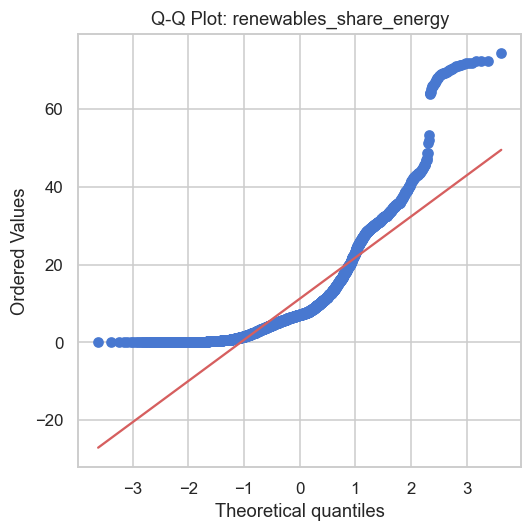

In [9]:
# Q-Q plot: confirms right skew, tail departs from the normal line
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(df[TARGET].dropna(), dist='norm', plot=ax)
ax.set_title('Q-Q Plot: renewables_share_energy')
plt.tight_layout()
plt.show()

---
## 4. Temporal Trends

Looking at how the global average renewable share has changed over time gives context for why we use a single cross-sectional year (2018) for the MLP: we want to capture a snapshot of the structural relationships, not a trend.

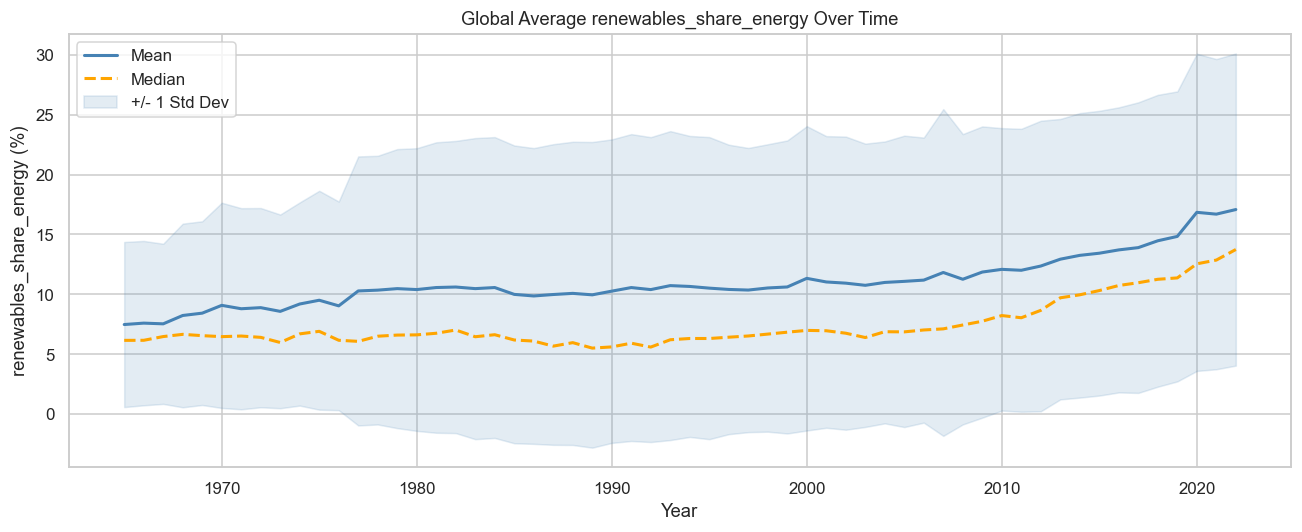

In [10]:
df_valid = df.dropna(subset=[TARGET]).copy()

yearly = df_valid.groupby('year')[TARGET].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly['year'], yearly['mean'],   label='Mean',   linewidth=2, color='steelblue')
ax.plot(yearly['year'], yearly['median'], label='Median', linewidth=2, color='orange', linestyle='--')
ax.fill_between(yearly['year'],
                yearly['mean'] - yearly['std'],
                yearly['mean'] + yearly['std'],
                alpha=0.15, color='steelblue', label='+/- 1 Std Dev')
ax.set_title('Global Average renewables_share_energy Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('renewables_share_energy (%)')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_44192\1706615583.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_year, labels=years_to_plot, patch_artist=True,


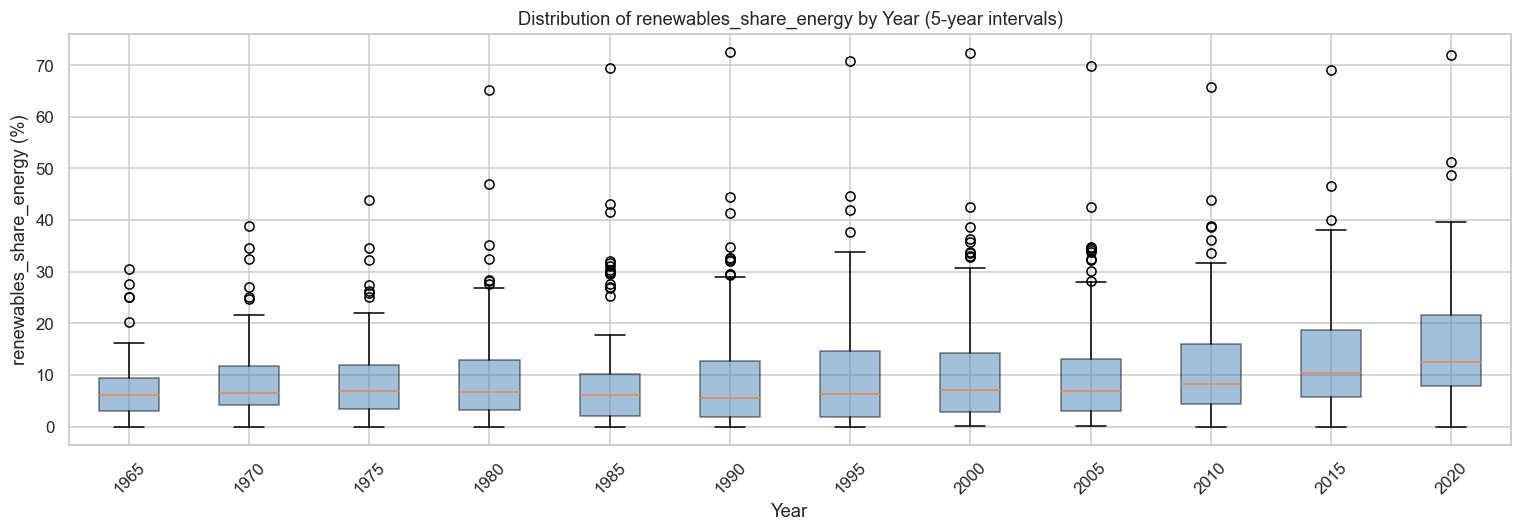

In [11]:
# Year-wise boxplots at 5-year intervals
years_to_plot = [y for y in sorted(df_valid['year'].unique()) if y % 5 == 0]
data_by_year = [df_valid[df_valid['year'] == y][TARGET].dropna().values for y in years_to_plot]

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data_by_year, labels=years_to_plot, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_title('Distribution of renewables_share_energy by Year (5-year intervals)')
ax.set_xlabel('Year')
ax.set_ylabel('renewables_share_energy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Country-Level Analysis

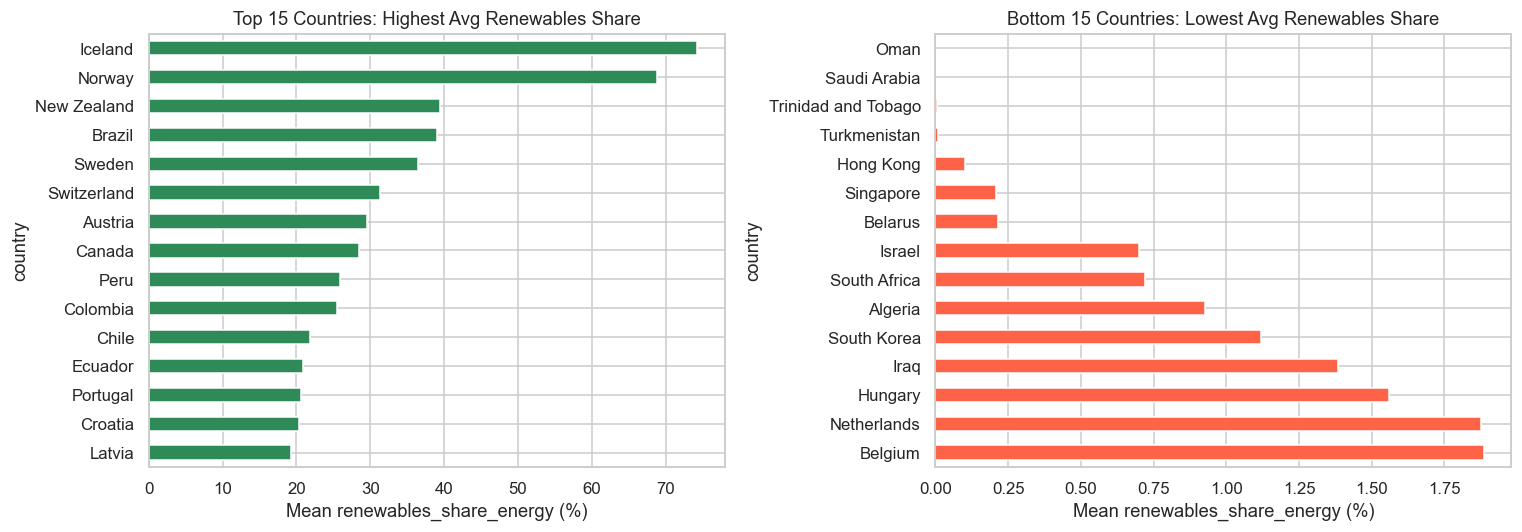

In [12]:
# Filter out aggregate regions (iso_code length 3 = sovereign country only)
df_countries = df_valid[
    df_valid['iso_code'].notna() & (df_valid['iso_code'].str.len() == 3)
]

country_avg = df_countries.groupby('country')[TARGET].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_avg.head(15).sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top 15 Countries: Highest Avg Renewables Share')
axes[0].set_xlabel('Mean renewables_share_energy (%)')

country_avg.tail(15).sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Bottom 15 Countries: Lowest Avg Renewables Share')
axes[1].set_xlabel('Mean renewables_share_energy (%)')

plt.tight_layout()
plt.show()

In [13]:
# Countries with >50% missing target values
missing_by_country = df.groupby('country')[TARGET].apply(lambda x: x.isna().mean())
high_missing = missing_by_country[missing_by_country > 0.5].sort_values(ascending=False)
print(f'Countries with >50% missing target values: {len(high_missing)}')
print(high_missing.head(20))

Countries with >50% missing target values: 278
country
Zimbabwe                     1.00
ASEAN (Ember)                1.00
Afghanistan                  1.00
Zambia                       1.00
Africa (Ember)               1.00
United Arab Emirates         1.00
Uganda                       1.00
U.S. Territories (EIA)       1.00
U.S. Pacific Islands (EIA)   1.00
Tuvalu                       1.00
Turks and Caicos Islands     1.00
Tunisia                      1.00
Tonga                        1.00
Togo                         1.00
Brunei                       1.00
British Virgin Islands       1.00
Botswana                     1.00
Bosnia and Herzegovina       1.00
Bolivia                      1.00
Bhutan                       1.00
Name: renewables_share_energy, dtype: float64


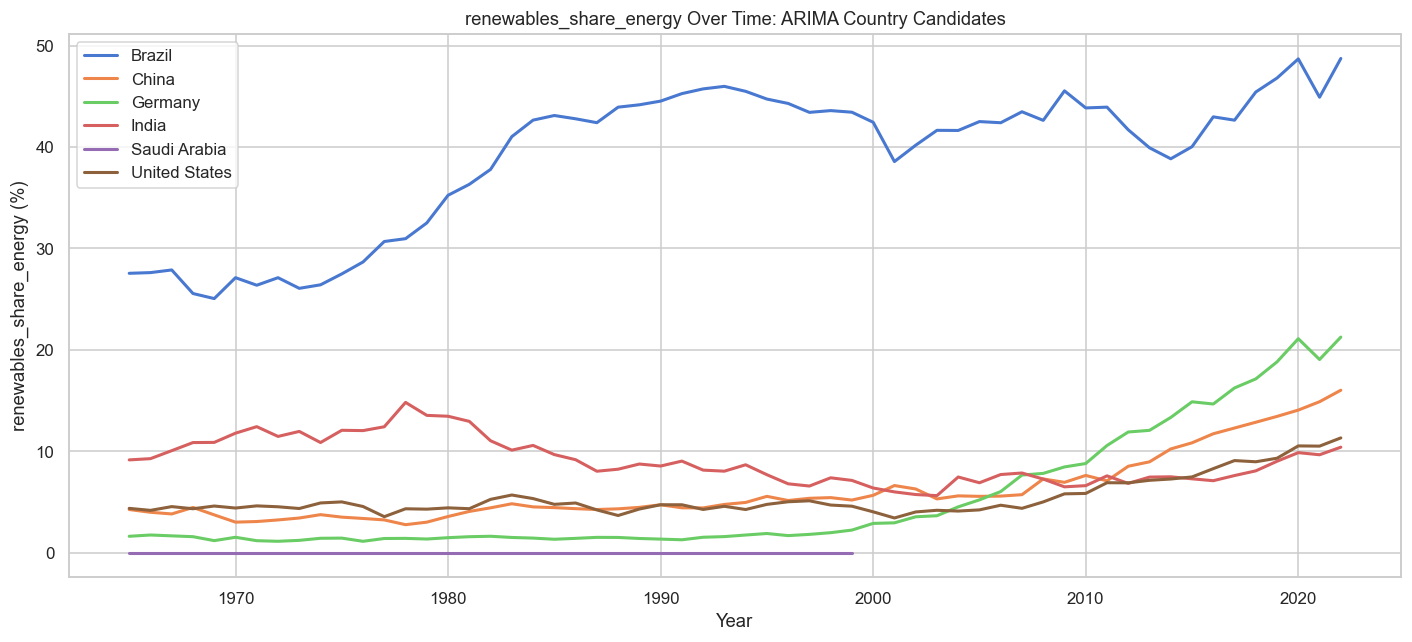

In [14]:
# Trajectories for the 5 countries selected for Model 3 (ARIMA)
# Saudi Arabia included here to illustrate why it was dropped (flat at 0%)
focus_countries = ['Germany', 'United States', 'China', 'India', 'Brazil', 'Saudi Arabia']
df_focus = df_countries[df_countries['country'].isin(focus_countries)]

fig, ax = plt.subplots(figsize=(13, 6))
for country, grp in df_focus.groupby('country'):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted[TARGET], label=country, linewidth=2)

ax.set_title('renewables_share_energy Over Time: ARIMA Country Candidates')
ax.set_xlabel('Year')
ax.set_ylabel('renewables_share_energy (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Correlation Analysis

We use the 2018 cross-section here (same slice as Model 1) to get correlations that are directly relevant to the modeling task. Using the full panel would mix time trends with cross-country variation.

**Key distinction - circular vs. predictive features:**
Many of the highest-correlated features are circular and cannot be used as model inputs:
- `hydro_share_energy` (r=0.90): hydro IS a component of renewables share, so this is tautological
- `fossil_share_energy` (r=-0.87): by definition, fossil + renewables approximately sum to 100
- `low_carbon_share_energy` (r=0.87): this includes renewables as a component

We need features that describe a country's structural and economic profile WITHOUT directly encoding its renewable mix.

In [15]:
# Correlations computed on the 2018 sovereign-country cross-section
df_2018 = df[
    (df['year'] == 2018) &
    df['iso_code'].notna() &
    (df['iso_code'].str.len() == 3)
].copy()

numeric_cols = df_2018.select_dtypes(include='number').columns.tolist()
corr_with_target = (
    df_2018[numeric_cols]
    .corr()[TARGET]
    .drop([TARGET, 'year'])
    .sort_values(key=abs, ascending=False)
)

print('Top 25 features correlated with renewables_share_energy (2018 cross-section):')
print(corr_with_target.head(25).to_string())

Top 25 features correlated with renewables_share_energy (2018 cross-section):
hydro_share_energy                    0.90
renewables_share_elec                 0.88
fossil_share_energy                  -0.87
low_carbon_share_energy               0.87
hydro_share_elec                      0.85
renewables_energy_per_capita          0.78
fossil_share_elec                    -0.77
low_carbon_share_elec                 0.77
renewables_elec_per_capita            0.77
low_carbon_energy_per_capita          0.73
hydro_energy_per_capita               0.72
hydro_elec_per_capita                 0.72
low_carbon_elec_per_capita            0.72
carbon_intensity_elec                -0.72
gas_share_elec                       -0.50
oil_prod_per_capita                   0.49
electricity_share_energy              0.48
per_capita_electricity                0.47
other_renewables_share_energy         0.43
gas_share_energy                     -0.43
wind_elec_per_capita                  0.42
wind_energy_per_cap

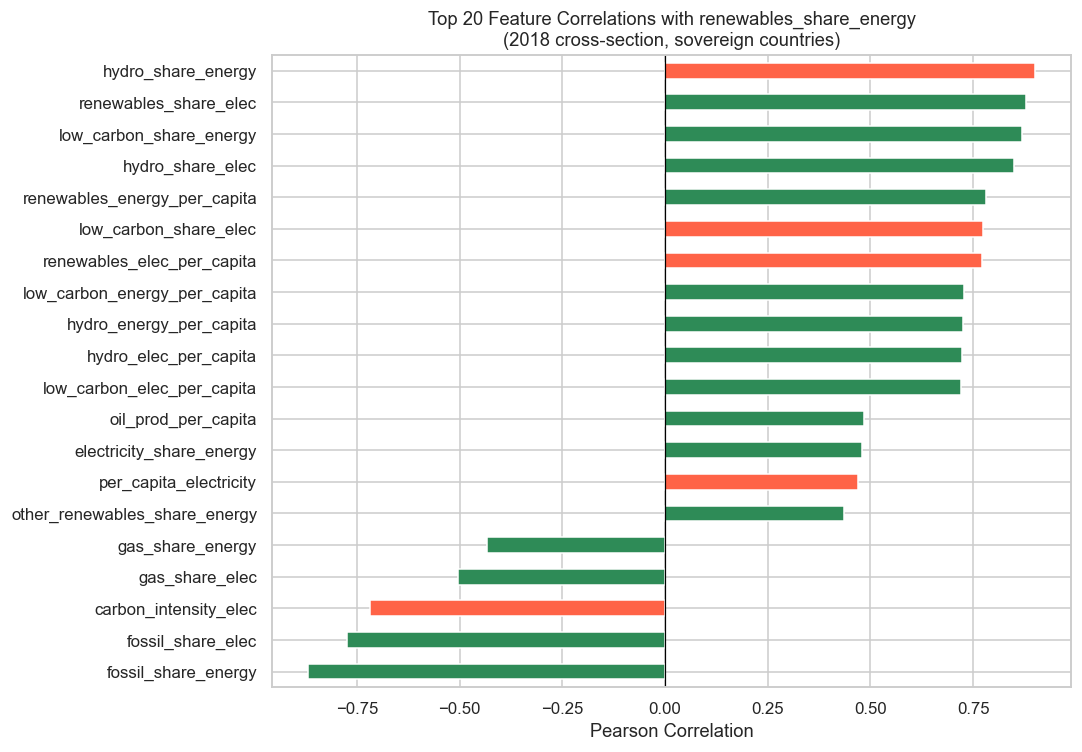

In [16]:
# Bar chart of top 20 correlations
top_corr = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['seagreen' if v > 0 else 'tomato' for v in top_corr.values]
top_corr.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Correlations with renewables_share_energy\n(2018 cross-section, sovereign countries)')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

---
## 7. Feature Selection: Circular vs. Non-Circular

This cell separates features into two groups and identifies the best non-circular candidates for the models. A feature is circular if it directly contains or is derived from renewable energy (e.g. `hydro_share_energy`, `fossil_share_energy`, `low_carbon_share_energy`). These would make the model trivially accurate but scientifically meaningless.

In [17]:
# Keywords that flag circular features
circular_keywords = [
    'renewables', 'hydro', 'low_carbon', 'fossil_share',
    'carbon_intensity', 'wind', 'solar', 'biofuel',
    'nuclear', 'other_renewables'
]

def is_circular(col):
    return any(kw in col for kw in circular_keywords)

safe_cols = [c for c in numeric_cols if not is_circular(c) and c not in [TARGET, 'year']]

corr_safe = df_2018[safe_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_safe_abs = corr_safe.abs().sort_values(ascending=False)

print('Best non-circular features correlated with target (2018):')
print(f'{"Feature":<45} {"r":>8}  {"missing (all 2018)":>20}')
print('-' * 78)
for feat in corr_safe_abs.head(20).index:
    r       = corr_safe[feat]
    missing = df_2018[feat].isna().mean() * 100
    print(f'{feat:<45} {r:>8.3f}  {missing:>19.1f}%')

Best non-circular features correlated with target (2018):
Feature                                              r    missing (all 2018)
------------------------------------------------------------------------------
gas_share_elec                                  -0.503                  6.4%
oil_prod_per_capita                              0.485                 77.6%
electricity_share_energy                         0.480                 63.9%
per_capita_electricity                           0.469                  2.3%
gas_share_energy                                -0.432                 68.5%
fossil_elec_per_capita                          -0.415                  2.3%
gas_elec_per_capita                             -0.366                  5.5%
gas_prod_per_capita                              0.325                 77.6%
gas_prod_change_pct                             -0.320                 69.9%
coal_share_elec                                 -0.310                  6.4%
coal_share_energ

In [18]:
# Show how the chosen features compare to the original spec features
original_features = [
    'gdp', 'coal_share_energy', 'oil_share_energy',
    'greenhouse_gas_emissions', 'energy_per_capita', 'energy_per_gdp', 'population'
]

chosen_features = [
    'gas_share_elec',
    'per_capita_electricity',
    'fossil_elec_per_capita',
    'gas_elec_per_capita',
    'coal_share_energy',
    'energy_per_gdp',
    'energy_per_capita',
]

print('Feature comparison: original spec vs. EDA-selected')
print(f'{"Feature":<40} {"Set":<12} {"r with target":>14}')
print('-' * 68)
for f in original_features:
    r = corr_safe[f] if f in corr_safe else float('nan')
    print(f'{f:<40} {"original":<12} {r:>14.3f}')
print()
for f in chosen_features:
    r = corr_safe[f] if f in corr_safe else float('nan')
    print(f'{f:<40} {"chosen":<12} {r:>14.3f}')

orig_mean = abs(pd.Series([corr_safe.get(f, 0) for f in original_features])).mean()
chosen_mean = abs(pd.Series([corr_safe.get(f, 0) for f in chosen_features])).mean()
print(f'\nMean |r|: original = {orig_mean:.3f}, chosen = {chosen_mean:.3f}')

Feature comparison: original spec vs. EDA-selected
Feature                                  Set           r with target
--------------------------------------------------------------------
gdp                                      original             -0.077
coal_share_energy                        original             -0.284
oil_share_energy                         original             -0.033
greenhouse_gas_emissions                 original             -0.088
energy_per_capita                        original              0.154
energy_per_gdp                           original             -0.187
population                               original             -0.084

gas_share_elec                           chosen               -0.503
per_capita_electricity                   chosen                0.469
fossil_elec_per_capita                   chosen               -0.415
gas_elec_per_capita                      chosen               -0.366
coal_share_energy                        chosen    

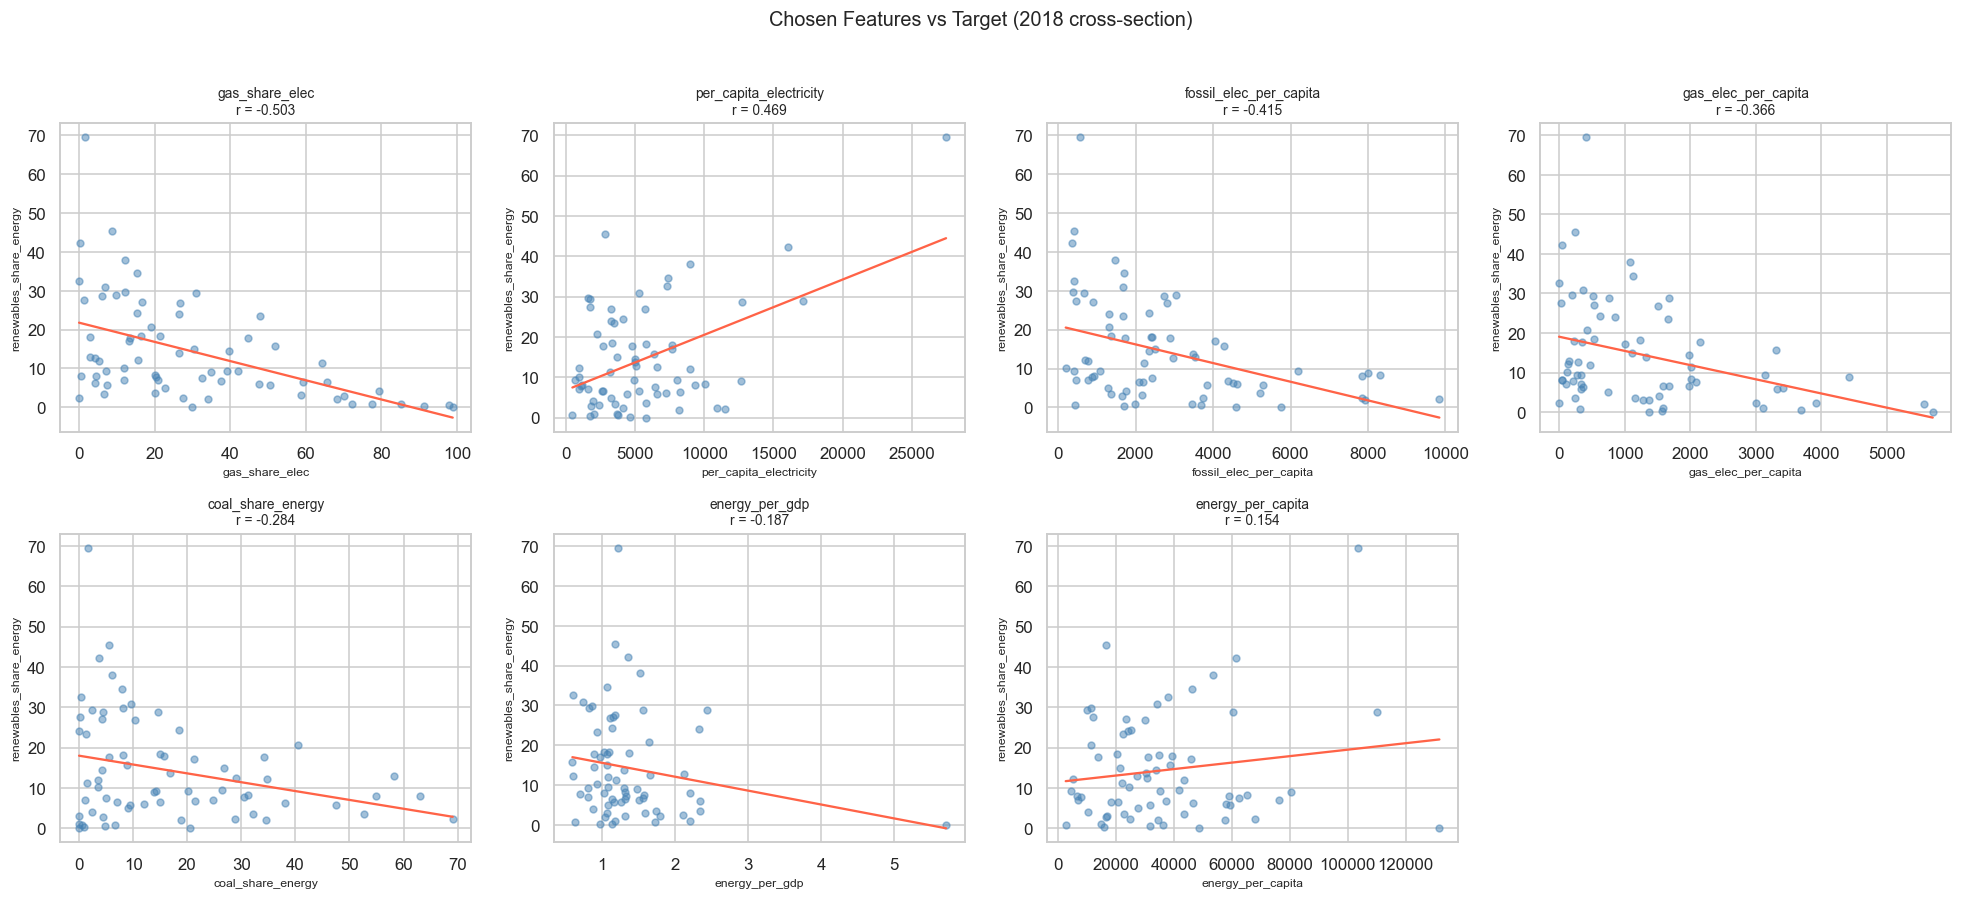

In [19]:
# Scatter plots: chosen features vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(chosen_features):
    tmp = df_2018[[TARGET, feat]].dropna()
    axes[i].scatter(tmp[feat], tmp[TARGET], alpha=0.5, s=20, color='steelblue')
    m, b = np.polyfit(tmp[feat], tmp[TARGET], 1)
    x_line = np.linspace(tmp[feat].min(), tmp[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='tomato', linewidth=1.5)
    r = tmp[[TARGET, feat]].corr().iloc[0, 1]
    axes[i].set_title(f'{feat}\nr = {r:.3f}', fontsize=9)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('renewables_share_energy', fontsize=8)

axes[-1].axis('off')  # hide unused 8th panel
plt.suptitle('Chosen Features vs Target (2018 cross-section)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Multicollinearity Check

High correlation between features can cause instability in regression models, particularly the Bayesian regression (Model 2). We flag pairs with |r| > 0.85 among the chosen features.

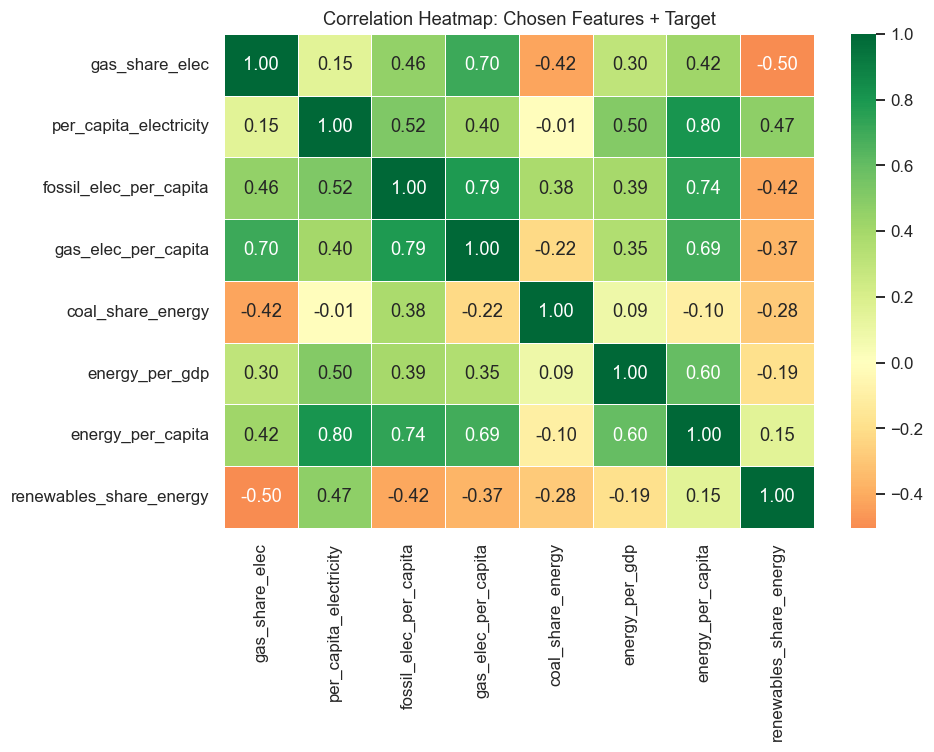

In [20]:
# Correlation heatmap among chosen features
corr_matrix = df_2018[chosen_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Chosen Features + Target')
plt.tight_layout()
plt.show()

In [21]:
# Flag high-correlation pairs among chosen features (|r| > 0.75)
feat_corr = df_2018[chosen_features].corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))

high_pairs = [
    (col, row, upper.at[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.at[row, col]) and upper.at[row, col] > 0.75
]

if high_pairs:
    high_df = pd.DataFrame(high_pairs, columns=['Feature A', 'Feature B', '|r|'])
    print('Feature pairs with |r| > 0.75 (watch for collinearity in Bayesian model):')
    print(high_df.sort_values('|r|', ascending=False).to_string(index=False))
else:
    print('No feature pairs with |r| > 0.75 among chosen features.')

Feature pairs with |r| > 0.75 (watch for collinearity in Bayesian model):
          Feature A              Feature B  |r|
  energy_per_capita per_capita_electricity 0.80
gas_elec_per_capita fossil_elec_per_capita 0.79


---
## 9. Outlier Investigation

Outliers in the target variable are not necessarily errors -- countries like Norway (nearly 70% renewables from hydro) or Trinidad and Tobago (near 0%) are genuine extreme cases and are part of the story we want to tell.

In [22]:
# IQR-based outlier detection
q1 = df[TARGET].quantile(0.25)
q3 = df[TARGET].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[(df[TARGET] < lower_fence) | (df[TARGET] > upper_fence)]
print(f'IQR fences   : [{lower_fence:.2f}, {upper_fence:.2f}]')
print(f'Outlier rows : {len(outliers):,} ({len(outliers)/n_total*100:.1f}%)')

print('\nTop countries appearing in outlier rows:')
print(outliers['country'].value_counts().head(15))

IQR fences   : [-13.59, 31.74]
Outlier rows : 333 (1.5%)

Top countries appearing in outlier rows:
country
New Zealand                       53
Norway                            46
Brazil                            44
South America                     31
Sweden                            29
Middle Africa (EI)                25
Switzerland                       24
Eastern Africa (EI)               21
Austria                           18
Colombia                          10
Peru                              10
Denmark                            5
South and Central America (EI)     5
Ecuador                            3
Finland                            3
Name: count, dtype: int64


In [23]:
# Extreme high-renewables records
print('Top 10 records with highest renewables_share_energy:')
df.nlargest(10, TARGET)[['country', 'year', TARGET, 'hydro_share_energy',
                          'wind_share_energy', 'solar_share_energy']]

Top 10 records with highest renewables_share_energy:


,country,year,renewables_share_energy,hydro_share_energy,wind_share_energy,solar_share_energy
9150,Iceland,2007,74.30,52.72,0.00,0.00
14558,Norway,1990,72.45,72.31,0.00,0.00
14568,Norway,2000,72.40,72.24,0.02,0.00
14589,Norway,2021,72.30,65.89,5.41,0.08
14551,Norway,1983,71.88,71.88,0.00,0.00
14588,Norway,2020,71.87,66.22,4.66,0.06
14560,Norway,1992,71.87,71.72,0.00,0.00
14590,Norway,2022,71.63,63.16,7.34,0.14
14557,Norway,1989,71.44,71.42,0.00,0.00
14559,Norway,1991,71.44,71.29,0.00,0.00


---
## 10. Pre/Post 2010 Segmentation

The cost of solar and wind dropped dramatically after 2010 (solar down ~90% per watt since 2010). If this structural break is real in the data, it has implications for how we interpret the MLP's cross-sectional predictions and the ARIMA forecasts.

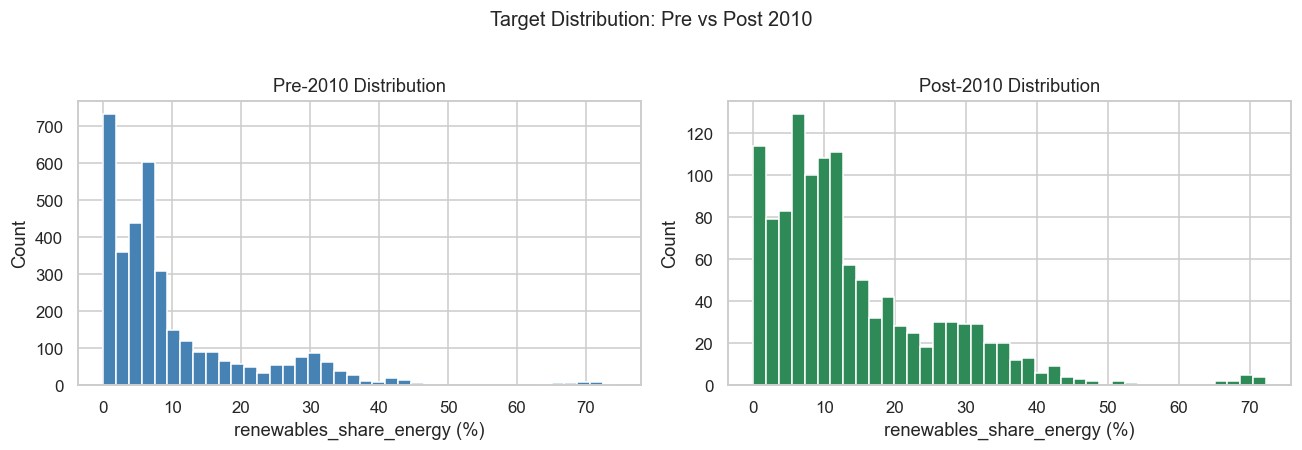

            count  mean   std  min  25%   50%   75%   max
era                                                      
Post-2010 1199.00 14.13 12.29 0.01 5.81 10.58 19.72 72.30
Pre-2010  3588.00 10.20 11.52 0.00 2.69  6.47 12.68 74.30


In [24]:
df_valid['era'] = df_valid['year'].apply(lambda y: 'Post-2010' if y >= 2010 else 'Pre-2010')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for era, grp in df_valid.groupby('era'):
    idx = 0 if era == 'Pre-2010' else 1
    axes[idx].hist(grp[TARGET].dropna(), bins=40,
                   color='steelblue' if era == 'Pre-2010' else 'seagreen',
                   edgecolor='white')
    axes[idx].set_title(f'{era} Distribution')
    axes[idx].set_xlabel('renewables_share_energy (%)')
    axes[idx].set_ylabel('Count')

plt.suptitle('Target Distribution: Pre vs Post 2010', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(df_valid.groupby('era')[TARGET].describe())

In [25]:
# Mann-Whitney U test: are the two era distributions significantly different?
pre = df_valid[df_valid['era'] == 'Pre-2010'][TARGET].dropna()
post = df_valid[df_valid['era'] == 'Post-2010'][TARGET].dropna()

stat, p = stats.mannwhitneyu(pre, post, alternative='two-sided')
print(f'Mann-Whitney U test: statistic={stat:.0f}, p-value={p:.4e}')
print('Interpretation:', 'Significant difference (p < 0.05)' if p < 0.05 else 'No significant difference')

Mann-Whitney U test: statistic=1586006, p-value=2.4050e-42
Interpretation: Significant difference (p < 0.05)
